In [ ]:
from pathlib import Path
import os
import subprocess

# ============================================================
# Paths
# ============================================================

RAW_ROOT = Path(
    "/home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329"
)

DERIV_ROOT = Path(
    "/home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007384"
)

SESSION = "ses-1"
TASK = "localizer"
N_SUBJECTS = 21


# ============================================================
# Helper: check whether a git-annex path exists as a link
# even when its file content has not yet been downloaded
# ============================================================

def annex_path_exists(path):
    return os.path.lexists(path)


# ============================================================
# Confirm that both roots are DataLad datasets
# ============================================================

for dataset_root in [RAW_ROOT, DERIV_ROOT]:

    if not dataset_root.exists():
        raise FileNotFoundError(
            f"Dataset directory does not exist:\n{dataset_root}"
        )

    result = subprocess.run(
        [
            "datalad",
            "status",
            "-d",
            str(dataset_root),
        ],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)

        raise RuntimeError(
            f"This does not appear to be a valid DataLad dataset:\n"
            f"{dataset_root}"
        )

    print(f"Confirmed DataLad dataset: {dataset_root}")


# ============================================================
# Find subjects and available localizer runs
# ============================================================

all_subjects = sorted(
    path.name
    for path in DERIV_ROOT.glob("sub-*")
    if path.is_dir()
)

subject_runs = {}

for subject in all_subjects:

    deriv_func_dir = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    if not deriv_func_dir.exists():
        continue

    # Use os.listdir rather than Path.glob alone because annexed files
    # may appear as broken symlinks before their content is downloaded.
    candidate_names = os.listdir(deriv_func_dir)

    left_surface_names = sorted(
        filename
        for filename in candidate_names
        if (
            filename.startswith(
                f"{subject}_{SESSION}_task-{TASK}_run-"
            )
            and filename.endswith(
                "_hemi-L_space-fsaverage6_bold.func.gii"
            )
        )
    )

    runs = []

    for filename in left_surface_names:

        run_parts = [
            part
            for part in filename.split("_")
            if part.startswith("run-")
        ]

        if run_parts:
            runs.append(run_parts[0])

    if runs:
        subject_runs[subject] = sorted(set(runs))


subjects = sorted(subject_runs.keys())[:N_SUBJECTS]

print(f"\nFound {len(subjects)} subjects to download:\n")

for subject in subjects:
    print(f"{subject}: {subject_runs[subject]}")

if len(subjects) == 0:
    raise RuntimeError(
        "No localizer subjects were found in the derivatives dataset."
    )


# ============================================================
# Build separate download lists for the two DataLad datasets
# ============================================================

derivative_files = []
raw_files = []

for subject in subjects:

    for run in subject_runs[subject]:

        base = (
            f"{subject}_{SESSION}_task-{TASK}_{run}"
        )

        deriv_func_dir = (
            DERIV_ROOT
            / subject
            / SESSION
            / "func"
        )

        raw_func_dir = (
            RAW_ROOT
            / subject
            / SESSION
            / "func"
        )

        expected_derivative_files = [
            deriv_func_dir
            / f"{base}_hemi-L_space-fsaverage6_bold.func.gii",

            deriv_func_dir
            / f"{base}_hemi-R_space-fsaverage6_bold.func.gii",

            deriv_func_dir
            / f"{base}_desc-confounds_timeseries.tsv",
        ]

        expected_raw_files = [
            raw_func_dir
            / f"{base}_events.tsv",
        ]

        for path in expected_derivative_files:

            if annex_path_exists(path):
                derivative_files.append(path)
            else:
                print(
                    "Missing derivative path; skipping:\n"
                    f"  {path}"
                )

        for path in expected_raw_files:

            if annex_path_exists(path):
                raw_files.append(path)
            else:
                print(
                    "Missing raw path; skipping:\n"
                    f"  {path}"
                )


# Remove any duplicates
derivative_files = sorted(set(derivative_files))
raw_files = sorted(set(raw_files))

print(
    f"\nDerivative files requested: {len(derivative_files)}"
)

print(
    f"Raw event files requested: {len(raw_files)}"
)


# ============================================================
# Convert absolute paths to paths relative to each dataset
# ============================================================

derivative_relative_paths = [
    str(path.relative_to(DERIV_ROOT))
    for path in derivative_files
]

raw_relative_paths = [
    str(path.relative_to(RAW_ROOT))
    for path in raw_files
]


# ============================================================
# Download derivative files
# ============================================================

if derivative_relative_paths:

    print("\nDownloading surface BOLD and confound files...\n")

    derivative_command = [
        "datalad",
        "get",
        "-d",
        str(DERIV_ROOT),
        "-J",
        "4",
        *derivative_relative_paths,
    ]

    print(
        "Running command from derivatives dataset:\n"
        f"  {DERIV_ROOT}"
    )

    subprocess.run(
        derivative_command,
        cwd=DERIV_ROOT,
        check=True,
    )


# ============================================================
# Download raw events files
# ============================================================

if raw_relative_paths:

    print("\nDownloading event files...\n")

    raw_command = [
        "datalad",
        "get",
        "-d",
        str(RAW_ROOT),
        "-J",
        "4",
        *raw_relative_paths,
    ]

    print(
        "Running command from raw dataset:\n"
        f"  {RAW_ROOT}"
    )

    subprocess.run(
        raw_command,
        cwd=RAW_ROOT,
        check=True,
    )


# ============================================================
# Verify downloaded content
# ============================================================

all_requested_files = (
    derivative_files
    + raw_files
)

downloaded_files = [
    path
    for path in all_requested_files
    if path.exists()
]

unavailable_files = [
    path
    for path in all_requested_files
    if not path.exists()
]

print("\n" + "=" * 70)

print(
    f"Downloaded and available: "
    f"{len(downloaded_files)}/{len(all_requested_files)}"
)

if unavailable_files:

    print(
        f"\nStill unavailable: {len(unavailable_files)}"
    )

    for path in unavailable_files:
        print(path)

else:

    print(
        "\nAll requested files are now locally available."
    )

print("=" * 70)

Total subject directories: 21
Subjects with at least one complete downloaded surface localizer run: 21
Subjects selected: 21

Selected subjects and runs:
  sub-sid000005: ['run-01', 'run-05']
  sub-sid000007: ['run-01', 'run-05']
  sub-sid000009: ['run-01', 'run-05']
  sub-sid000010: ['run-01', 'run-05']
  sub-sid000013: ['run-01', 'run-05']
  sub-sid000020: ['run-01', 'run-05']
  sub-sid000021: ['run-01', 'run-05']
  sub-sid000024: ['run-01', 'run-05']
  sub-sid000029: ['run-01', 'run-05']
  sub-sid000034: ['run-01', 'run-05']
  sub-sid000052: ['run-01', 'run-05']
  sub-sid000114: ['run-01', 'run-05']
  sub-sid000120: ['run-01', 'run-05']
  sub-sid000134: ['run-01', 'run-05']
  sub-sid000142: ['run-01', 'run-05']
  sub-sid000278: ['run-01', 'run-05']
  sub-sid000416: ['run-01', 'run-05']
  sub-sid000499: ['run-01', 'run-05']
  sub-sid000522: ['run-01', 'run-05']
  sub-sid000535: ['run-01', 'run-05']
  sub-sid000560: ['run-01', 'run-05']

Processing subject 1/21: sub-sid000005

Process

/tmp/ipykernel_2523/1599219594.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...

Processing run-05
Left surface shape: (236, 40962)
Right surface shape: (236, 40962)
TR for sub-sid000005 run-05: 1.0 seconds
TR source: /home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329/sub-sid000005/ses-1/func/sub-sid000005_ses-1_task-localizer_run-05_bold.json
Conditions in design: ['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects']
Design matrix shape: (236, 17)
Design matrix columns:
['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'constant']
Fitting left hemisphere...


/tmp/ipykernel_2523/1599219594.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...
Completed sub-sid000005

Processing subject 2/21: sub-sid000007

Processing run-01
Left surface shape: (236, 40962)
Right surface shape: (236, 40962)
TR for sub-sid000007 run-01: 1.0 seconds
TR source: /home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329/sub-sid000007/ses-1/func/sub-sid000007_ses-1_task-localizer_run-01_bold.json
Conditions in design: ['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects']
Design matrix shape: (236, 17)
Design matrix columns:
['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'constant']
Fitting left hemisphere...


...

/tmp/ipykernel_2523/1599219594.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...

Processing run-05
Left surface shape: (236, 40962)
Right surface shape: (236, 40962)
TR for sub-sid000560 run-05: 1.0 seconds
TR source: /home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329/sub-sid000560/ses-1/func/sub-sid000560_ses-1_task-localizer_run-05_bold.json
Conditions in design: ['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects']
Design matrix shape: (236, 17)
Design matrix columns:
['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'constant']
Fitting left hemisphere...


/tmp/ipykernel_2523/1599219594.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...
Completed sub-sid000560

Processing summary:
      subject          runs  number_of_runs  left_vertices  right_vertices   status
sub-sid000005 run-01,run-05               2          40962           40962 complete
sub-sid000007 run-01,run-05               2          40962           40962 complete
sub-sid000009 run-01,run-05               2          40962           40962 complete
sub-sid000010 run-01,run-05               2          40962           40962 complete
sub-sid000013 run-01,run-05               2          40962           40962 complete
sub-sid000020 run-01,run-05               2          40962           40962 complete
sub-sid000021 run-01,run-05               2          40962           40962 complete
sub-sid000024 run-01,run-05               2          40962           40962 complete
sub-sid000029 run-01,run-05               2          40962           40962 complete
sub-sid000034 run-01,run-05               2          40962           40962 complete
sub

[fetch_surf_fsaverage] Dataset found in /home/jovyan/nilearn_data/fsaverage6

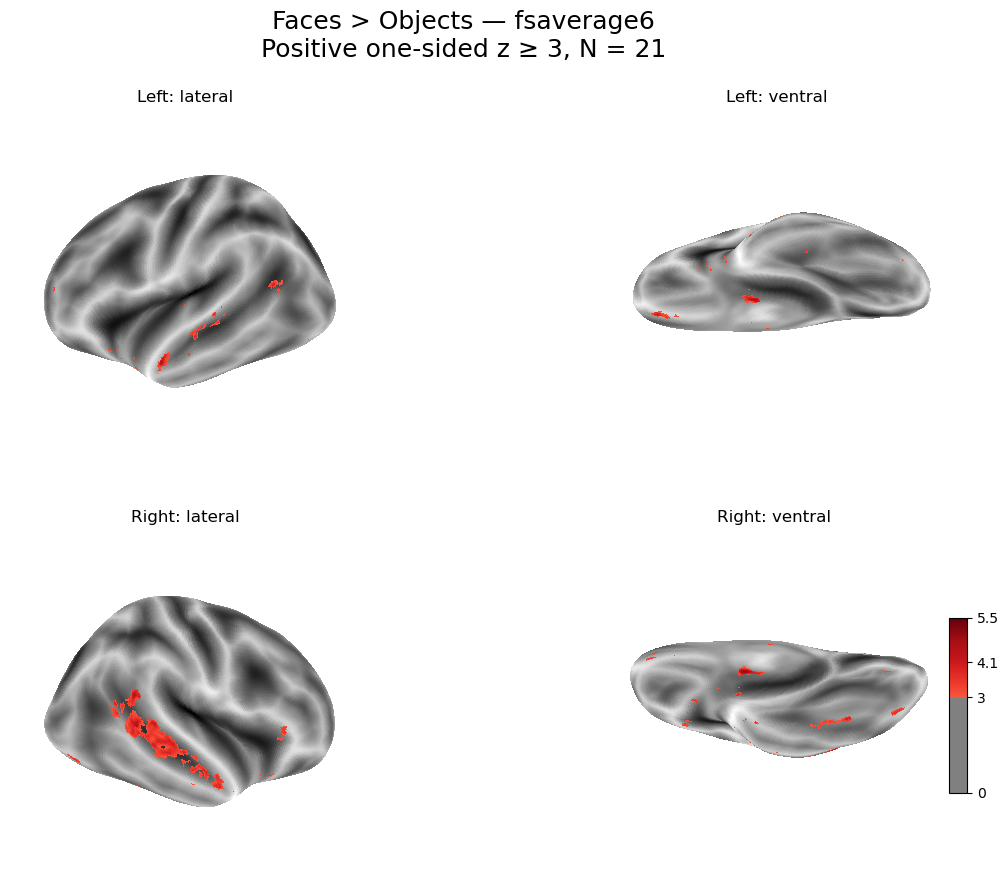

Saved figure:
/home/jovyan/heather_analysis/group_surface_faces_vs_objects/figures/group_N21_facesGreaterThanObjects_positive_z3_surface.png


[fetch_surf_fsaverage] Dataset found in /home/jovyan/nilearn_data/fsaverage6

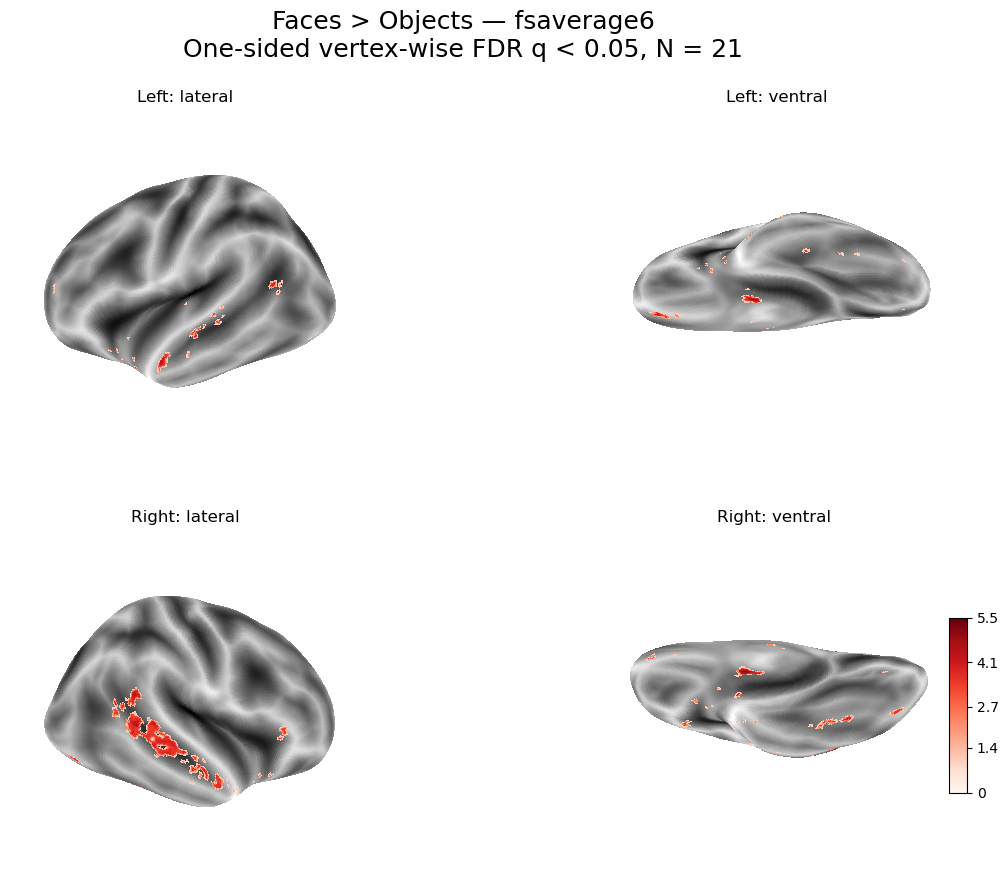

Saved figure:
/home/jovyan/heather_analysis/group_surface_faces_vs_objects/figures/group_N21_facesGreaterThanObjects_oneSidedFDRq05_surface.png


[fetch_surf_fsaverage] Dataset found in /home/jovyan/nilearn_data/fsaverage6


Analysis complete.
Display the right interactive viewer in the next notebook cell by running:
right_interactive_fdr


In [2]:
# ============================================================
# HyperFace surface group analysis
#
# Contrast:
#     Faces > Objects
#
# Analysis:
#     1. Use 21 subjects with downloaded localizer data
#     2. Fit first-level surface GLMs
#     3. Combine multiple runs within subjects using fixed effects
#     4. Run a group one-sample t-test
#     5. Apply one-sided Benjamini-Hochberg FDR across both hemispheres
#     6. Save maps and create final surface figures
#
# Required packages:
#     numpy, pandas, nibabel, nilearn, scipy, statsmodels, matplotlib
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from nilearn import datasets, plotting
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.glm.contrasts import expression_to_contrast_vector


# ============================================================
# 2. Paths and analysis settings
# ============================================================

RAW_ROOT = Path(
    "/home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329"
)

DERIV_ROOT = Path(
    "/home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007384"
)

OUTPUT_ROOT = Path(
    "/home/jovyan/heather_analysis/group_surface_faces_vs_objects"
)

SUBJECT_OUTPUT_DIR = OUTPUT_ROOT / "subject_maps"
GROUP_OUTPUT_DIR = OUTPUT_ROOT / "group_maps"
FIGURE_OUTPUT_DIR = OUTPUT_ROOT / "figures"

for output_directory in [
    SUBJECT_OUTPUT_DIR,
    GROUP_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


SESSION = "ses-1"
TASK = "localizer"

N_SUBJECTS = 21

CONTRAST_EXPRESSION = "faces - objects"

HRF_MODEL = "glover"
DRIFT_MODEL = "cosine"
HIGH_PASS = 1 / 128

FDR_ALPHA = 0.05

UNCORRECTED_Z_THRESHOLD = 3.0

MOTION_COLUMNS = [
    "trans_x",
    "trans_y",
    "trans_z",
    "rot_x",
    "rot_y",
    "rot_z",
]


# ============================================================
# 3. Helper functions
# ============================================================

def path_content_exists(path):
    """
    Return True only when a file exists and its annexed content
    is available locally.

    os.path.lexists() would also return True for broken git-annex
    links, so Path.exists() is used here.
    """

    return Path(path).exists()


def extract_run_label(filename):
    """
    Extract a run label such as run-01 from a BIDS filename.
    """

    pieces = filename.split("_")

    run_pieces = [
        piece
        for piece in pieces
        if piece.startswith("run-")
    ]

    if not run_pieces:
        return None

    return run_pieces[0]


def get_run_files(subject, run):
    """
    Construct expected file paths for one subject and localizer run.
    """

    base = (
        f"{subject}_{SESSION}_task-{TASK}_{run}"
    )

    raw_func_dir = (
        RAW_ROOT
        / subject
        / SESSION
        / "func"
    )

    deriv_func_dir = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    return {
        "left_bold": (
            deriv_func_dir
            / (
                f"{base}_hemi-L_"
                "space-fsaverage6_bold.func.gii"
            )
        ),
        "right_bold": (
            deriv_func_dir
            / (
                f"{base}_hemi-R_"
                "space-fsaverage6_bold.func.gii"
            )
        ),
        "confounds": (
            deriv_func_dir
            / f"{base}_desc-confounds_timeseries.tsv"
        ),
        "events": (
            raw_func_dir
            / f"{base}_events.tsv"
        ),
    }


def find_json_sidecar(subject, run):
    """
    Search likely raw and derivative locations for a JSON sidecar
    containing RepetitionTime.
    """

    raw_func_dir = (
        RAW_ROOT
        / subject
        / SESSION
        / "func"
    )

    deriv_func_dir = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    base = (
        f"{subject}_{SESSION}_task-{TASK}_{run}"
    )

    candidates = [
        raw_func_dir / f"{base}_bold.json",
        deriv_func_dir / f"{base}_bold.json",
        deriv_func_dir / f"{base}_space-T1w_desc-preproc_bold.json",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    broader_candidates = sorted(
        list(raw_func_dir.glob(f"{base}*bold.json"))
        + list(deriv_func_dir.glob(f"{base}*bold.json"))
    )

    if broader_candidates:
        return broader_candidates[0]

    return None


def read_repetition_time(subject, run):
    """
    Read RepetitionTime from a BIDS JSON sidecar.

    The function also checks task-level JSON files when no run-level
    JSON file is present.
    """

    run_json = find_json_sidecar(
        subject,
        run,
    )

    candidate_jsons = []

    if run_json is not None:
        candidate_jsons.append(run_json)

    candidate_jsons.extend(
        [
            RAW_ROOT
            / f"task-{TASK}_bold.json",

            RAW_ROOT
            / subject
            / SESSION
            / "func"
            / f"task-{TASK}_bold.json",

            DERIV_ROOT
            / f"task-{TASK}_bold.json",
        ]
    )

    for json_file in candidate_jsons:
        if not json_file.exists():
            continue

        with open(json_file, "r") as file:
            metadata = json.load(file)

        if "RepetitionTime" in metadata:
            repetition_time = float(
                metadata["RepetitionTime"]
            )

            print(
                f"TR for {subject} {run}: "
                f"{repetition_time} seconds"
            )

            print(
                f"TR source: {json_file}"
            )

            return repetition_time

    raise FileNotFoundError(
        f"Could not find RepetitionTime for {subject} {run}. "
        "Check the raw or derivative BIDS JSON sidecars."
    )


def load_surface_timeseries(gifti_file):
    """
    Load a functional GIFTI file.

    Returns
    -------
    data : ndarray
        Shape is scans x vertices.
    """

    gifti_image = nib.load(
        str(gifti_file)
    )

    data_arrays = [
        np.asarray(
            data_array.data,
            dtype=np.float64,
        )
        for data_array in gifti_image.darrays
    ]

    if len(data_arrays) == 0:
        raise ValueError(
            f"No data arrays found in {gifti_file}"
        )

    data = np.vstack(data_arrays)

    if data.ndim != 2:
        raise ValueError(
            f"Unexpected GIFTI data shape for {gifti_file}: "
            f"{data.shape}"
        )

    return data


def save_surface_map(
    values,
    output_file,
    intent="NIFTI_INTENT_NONE",
):
    """
    Save a one-dimensional surface map as a GIFTI file.
    """

    values = np.asarray(
        values,
        dtype=np.float32,
    )

    gifti_image = nib.gifti.GiftiImage(
        darrays=[
            nib.gifti.GiftiDataArray(
                data=values,
                intent=intent,
            )
        ]
    )

    nib.save(
        gifti_image,
        str(output_file),
    )


def identify_event_column(events_dataframe):
    """
    Identify the column containing localizer condition labels.
    """

    candidate_columns = [
        "stim_type",
        "trial_type",
        "condition",
        "category",
    ]

    for column in candidate_columns:
        if column in events_dataframe.columns:
            return column

    raise ValueError(
        "Could not identify the event-condition column. "
        f"Available columns are: "
        f"{events_dataframe.columns.tolist()}"
    )


def standardize_condition_names(series):
    """
    Standardize condition labels for contrast construction.
    """

    standardized = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    replacements = {
        "face": "faces",
        "object": "objects",
        "body": "bodies",
        "scene": "scenes",
        "scrambled_object": "scrambled_objects",
    }

    return standardized.replace(replacements)


def build_design_matrix(
    events_file,
    confounds_file,
    n_scans,
    repetition_time,
):
    """
    Build the first-level design matrix and Faces > Objects
    contrast vector for one run.
    """

    events_raw = pd.read_csv(
        events_file,
        sep="\t",
    )

    condition_column = identify_event_column(
        events_raw
    )

    required_event_columns = [
        "onset",
        "duration",
        condition_column,
    ]

    missing_event_columns = [
        column
        for column in required_event_columns
        if column not in events_raw.columns
    ]

    if missing_event_columns:
        raise ValueError(
            f"Missing event columns in {events_file}: "
            f"{missing_event_columns}"
        )

    events = events_raw[
        required_event_columns
    ].copy()

    events = events.rename(
        columns={
            condition_column: "trial_type"
        }
    )

    events["trial_type"] = standardize_condition_names(
        events["trial_type"]
    )

    available_conditions = sorted(
        events["trial_type"]
        .dropna()
        .unique()
        .tolist()
    )

    print(
        "Conditions in design:",
        available_conditions,
    )

    for required_condition in [
        "faces",
        "objects",
    ]:
        if required_condition not in available_conditions:
            raise ValueError(
                f"Condition '{required_condition}' was not found "
                f"in {events_file}. Conditions found: "
                f"{available_conditions}"
            )

    confounds_raw = pd.read_csv(
        confounds_file,
        sep="\t",
    )

    missing_motion_columns = [
        column
        for column in MOTION_COLUMNS
        if column not in confounds_raw.columns
    ]

    if missing_motion_columns:
        raise ValueError(
            f"Missing motion regressors in {confounds_file}: "
            f"{missing_motion_columns}"
        )

    confounds = (
        confounds_raw[MOTION_COLUMNS]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .reset_index(drop=True)
    )

    if len(confounds) != n_scans:
        raise ValueError(
            f"Confound rows ({len(confounds)}) do not match "
            f"surface scans ({n_scans}) for {events_file}."
        )

    frame_times = (
        np.arange(n_scans, dtype=float)
        * repetition_time
    )

    design_matrix = make_first_level_design_matrix(
        frame_times=frame_times,
        events=events[
            ["onset", "duration", "trial_type"]
        ],
        hrf_model=HRF_MODEL,
        drift_model=DRIFT_MODEL,
        high_pass=HIGH_PASS,
        add_regs=confounds.to_numpy(),
        add_reg_names=MOTION_COLUMNS,
    )

    contrast_vector = (
        expression_to_contrast_vector(
            CONTRAST_EXPRESSION,
            design_matrix.columns,
        )
    )

    return design_matrix, contrast_vector


def fit_surface_ols(
    surface_data,
    design_matrix,
    contrast_vector,
):
    """
    Fit an ordinary least-squares GLM at every surface vertex.

    Returns
    -------
    effect : ndarray
        Faces-minus-objects contrast estimate.

    variance : ndarray
        Estimated variance of the contrast estimate.

    t_values : ndarray
        First-level contrast t statistics.
    """

    Y = np.asarray(
        surface_data,
        dtype=np.float64,
    )

    X = np.asarray(
        design_matrix,
        dtype=np.float64,
    )

    contrast = np.asarray(
        contrast_vector,
        dtype=np.float64,
    )

    if Y.shape[0] != X.shape[0]:
        raise ValueError(
            f"Surface scans ({Y.shape[0]}) do not match "
            f"design rows ({X.shape[0]})."
        )

    finite_data_mask = np.all(
        np.isfinite(Y),
        axis=0,
    )

    Y_clean = np.nan_to_num(
        Y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    design_pseudoinverse = np.linalg.pinv(X)

    beta = (
        design_pseudoinverse
        @ Y_clean
    )

    fitted = X @ beta

    residuals = (
        Y_clean
        - fitted
    )

    design_rank = np.linalg.matrix_rank(X)

    residual_degrees_of_freedom = (
        X.shape[0]
        - design_rank
    )

    if residual_degrees_of_freedom <= 0:
        raise ValueError(
            "The first-level model has no residual "
            "degrees of freedom."
        )

    residual_variance = (
        np.sum(
            residuals ** 2,
            axis=0,
        )
        / residual_degrees_of_freedom
    )

    xtx_inverse = np.linalg.pinv(
        X.T @ X
    )

    contrast_scale = float(
        contrast.T
        @ xtx_inverse
        @ contrast
    )

    effect = contrast @ beta

    variance = (
        residual_variance
        * contrast_scale
    )

    valid_variance_mask = (
        finite_data_mask
        & np.isfinite(effect)
        & np.isfinite(variance)
        & (variance > 0)
    )

    t_values = np.zeros_like(
        effect,
        dtype=float,
    )

    t_values[valid_variance_mask] = (
        effect[valid_variance_mask]
        / np.sqrt(
            variance[valid_variance_mask]
        )
    )

    effect[~finite_data_mask] = 0
    variance[~valid_variance_mask] = np.inf

    return effect, variance, t_values


def fixed_effects_combine(
    effects,
    variances,
):
    """
    Combine multiple localizer runs within a subject using
    inverse-variance fixed effects.
    """

    effects = np.asarray(
        effects,
        dtype=np.float64,
    )

    variances = np.asarray(
        variances,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(effects)
        & np.isfinite(variances)
        & (variances > 0)
    )

    weights = np.zeros_like(
        variances,
        dtype=float,
    )

    weights[valid] = (
        1.0
        / variances[valid]
    )

    weight_sum = np.sum(
        weights,
        axis=0,
    )

    combined_effect = np.zeros(
        effects.shape[1],
        dtype=float,
    )

    combined_variance = np.full(
        effects.shape[1],
        np.inf,
        dtype=float,
    )

    valid_vertices = weight_sum > 0

    weighted_effect_sum = np.sum(
        weights * effects,
        axis=0,
    )

    combined_effect[valid_vertices] = (
        weighted_effect_sum[valid_vertices]
        / weight_sum[valid_vertices]
    )

    combined_variance[valid_vertices] = (
        1.0
        / weight_sum[valid_vertices]
    )

    return combined_effect, combined_variance


def group_one_sample_test(subject_effects):
    """
    Perform a vertex-wise one-sample t-test across subjects.

    Returns
    -------
    group_mean
    group_t
    group_z_two_sided
    valid_vertices
    """

    subject_effects = np.asarray(
        subject_effects,
        dtype=np.float64,
    )

    n_subjects = subject_effects.shape[0]

    group_mean = np.mean(
        subject_effects,
        axis=0,
    )

    group_standard_deviation = np.std(
        subject_effects,
        axis=0,
        ddof=1,
    )

    group_standard_error = (
        group_standard_deviation
        / np.sqrt(n_subjects)
    )

    # Exclude medial-wall and constant vertices.
    nonzero_across_subjects = np.any(
        np.abs(subject_effects) > 1e-12,
        axis=0,
    )

    valid_vertices = (
        np.all(
            np.isfinite(subject_effects),
            axis=0,
        )
        & np.isfinite(group_mean)
        & np.isfinite(group_standard_error)
        & (group_standard_error > 0)
        & nonzero_across_subjects
    )

    group_t = np.zeros_like(
        group_mean,
        dtype=float,
    )

    group_t[valid_vertices] = (
        group_mean[valid_vertices]
        / group_standard_error[valid_vertices]
    )

    degrees_of_freedom = (
        n_subjects - 1
    )

    two_sided_p = np.ones_like(
        group_t,
        dtype=float,
    )

    two_sided_p[valid_vertices] = (
        2
        * stats.t.sf(
            np.abs(
                group_t[valid_vertices]
            ),
            df=degrees_of_freedom,
        )
    )

    two_sided_p = np.clip(
        two_sided_p,
        np.finfo(float).tiny,
        1.0,
    )

    group_z_two_sided = np.zeros_like(
        group_t,
        dtype=float,
    )

    group_z_two_sided[valid_vertices] = (
        stats.norm.isf(
            two_sided_p[valid_vertices]
            / 2
        )
        * np.sign(
            group_t[valid_vertices]
        )
    )

    return (
        group_mean,
        group_t,
        group_z_two_sided,
        valid_vertices,
    )


def plot_surface_four_views(
    left_stat_map,
    right_stat_map,
    figure_title,
    output_file,
    threshold,
    cmap="Reds",
    symmetric_cbar=False,
    vmax=None,
):
    """
    Create left/right lateral and ventral surface plots.
    """

    fsaverage = datasets.fetch_surf_fsaverage(
        mesh="fsaverage6"
    )

    views = [
        ("left", "lateral"),
        ("left", "ventral"),
        ("right", "lateral"),
        ("right", "ventral"),
    ]

    figure = plt.figure(
        figsize=(14, 10)
    )

    for plot_number, (
        hemisphere,
        view,
    ) in enumerate(
        views,
        start=1,
    ):

        axis = figure.add_subplot(
            2,
            2,
            plot_number,
            projection="3d",
        )

        if hemisphere == "left":
            stat_map = left_stat_map
            surface_mesh = fsaverage.infl_left
            background_map = fsaverage.sulc_left
            hemisphere_label = "Left"
        else:
            stat_map = right_stat_map
            surface_mesh = fsaverage.infl_right
            background_map = fsaverage.sulc_right
            hemisphere_label = "Right"

        plotting.plot_surf_stat_map(
            surf_mesh=surface_mesh,
            stat_map=stat_map,
            bg_map=background_map,
            hemi=hemisphere,
            view=view,
            threshold=threshold,
            cmap=cmap,
            symmetric_cbar=symmetric_cbar,
            vmax=vmax,
            colorbar=(plot_number == 4),
            title=(
                f"{hemisphere_label}: "
                f"{view}"
            ),
            axes=axis,
        )

    figure.suptitle(
        figure_title,
        fontsize=18,
        y=0.98,
    )

    figure.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved figure:\n{output_file}"
    )


# ============================================================
# 4. Discover complete downloaded localizer runs
# ============================================================

all_subjects = sorted(
    [
        path.name
        for path in DERIV_ROOT.glob("sub-*")
        if path.is_dir()
    ]
)

subject_runs = {}

for subject in all_subjects:

    derivative_func_directory = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    if not derivative_func_directory.exists():
        continue

    left_candidates = sorted(
        derivative_func_directory.glob(
            (
                f"{subject}_{SESSION}_"
                f"task-{TASK}_run-*_"
                "hemi-L_space-fsaverage6_bold.func.gii"
            )
        )
    )

    complete_runs = []

    for left_candidate in left_candidates:

        run = extract_run_label(
            left_candidate.name
        )

        if run is None:
            continue

        files = get_run_files(
            subject,
            run,
        )

        if all(
            path_content_exists(path)
            for path in files.values()
        ):
            complete_runs.append(run)

    if complete_runs:
        subject_runs[subject] = sorted(
            set(complete_runs)
        )


eligible_subjects = sorted(
    subject_runs.keys()
)

subjects = eligible_subjects[
    :N_SUBJECTS
]

print(
    "Total subject directories:",
    len(all_subjects),
)

print(
    "Subjects with at least one complete downloaded "
    "surface localizer run:",
    len(eligible_subjects),
)

print(
    "Subjects selected:",
    len(subjects),
)

print(
    "\nSelected subjects and runs:"
)

for subject in subjects:
    print(
        f"  {subject}: "
        f"{subject_runs[subject]}"
    )

if len(subjects) == 0:
    raise RuntimeError(
        "No complete downloaded localizer surface data were found."
    )

if len(subjects) < N_SUBJECTS:
    warnings.warn(
        f"Only {len(subjects)} complete subjects were found. "
        f"The analysis will use those subjects rather than "
        f"the requested {N_SUBJECTS}."
    )


# ============================================================
# 5. Fit first-level GLMs and combine runs within subjects
# ============================================================

left_subject_effects = []
right_subject_effects = []

processing_rows = []

expected_left_vertices = None
expected_right_vertices = None


for subject_index, subject in enumerate(
    subjects,
    start=1,
):

    print("\n" + "=" * 80)

    print(
        f"Processing subject "
        f"{subject_index}/{len(subjects)}: "
        f"{subject}"
    )

    print("=" * 80)

    available_runs = subject_runs[
        subject
    ]

    left_run_effects = []
    left_run_variances = []

    right_run_effects = []
    right_run_variances = []

    successful_runs = []

    for run in available_runs:

        print(
            f"\nProcessing {run}"
        )

        files = get_run_files(
            subject,
            run,
        )

        left_data = load_surface_timeseries(
            files["left_bold"]
        )

        right_data = load_surface_timeseries(
            files["right_bold"]
        )

        print(
            "Left surface shape:",
            left_data.shape,
        )

        print(
            "Right surface shape:",
            right_data.shape,
        )

        if (
            left_data.shape[0]
            != right_data.shape[0]
        ):
            raise ValueError(
                f"{subject} {run}: left and right hemispheres "
                "have different numbers of scans."
            )

        if expected_left_vertices is None:
            expected_left_vertices = (
                left_data.shape[1]
            )

            expected_right_vertices = (
                right_data.shape[1]
            )

        if (
            left_data.shape[1]
            != expected_left_vertices
        ):
            raise ValueError(
                f"{subject} {run}: unexpected number of "
                "left-hemisphere vertices."
            )

        if (
            right_data.shape[1]
            != expected_right_vertices
        ):
            raise ValueError(
                f"{subject} {run}: unexpected number of "
                "right-hemisphere vertices."
            )

        repetition_time = read_repetition_time(
            subject,
            run,
        )

        (
            design_matrix,
            contrast_vector,
        ) = build_design_matrix(
            events_file=files["events"],
            confounds_file=files["confounds"],
            n_scans=left_data.shape[0],
            repetition_time=repetition_time,
        )

        print(
            "Design matrix shape:",
            design_matrix.shape,
        )

        print(
            "Design matrix columns:"
        )

        print(
            design_matrix.columns.tolist()
        )

        print(
            "Fitting left hemisphere..."
        )

        (
            left_effect,
            left_variance,
            left_t,
        ) = fit_surface_ols(
            surface_data=left_data,
            design_matrix=design_matrix,
            contrast_vector=contrast_vector,
        )

        print(
            "Fitting right hemisphere..."
        )

        (
            right_effect,
            right_variance,
            right_t,
        ) = fit_surface_ols(
            surface_data=right_data,
            design_matrix=design_matrix,
            contrast_vector=contrast_vector,
        )

        left_run_effects.append(
            left_effect
        )

        left_run_variances.append(
            left_variance
        )

        right_run_effects.append(
            right_effect
        )

        right_run_variances.append(
            right_variance
        )

        successful_runs.append(run)

        np.save(
            SUBJECT_OUTPUT_DIR
            / (
                f"{subject}_{run}_hemi-L_"
                "facesMinusObjects_effect.npy"
            ),
            left_effect,
        )

        np.save(
            SUBJECT_OUTPUT_DIR
            / (
                f"{subject}_{run}_hemi-R_"
                "facesMinusObjects_effect.npy"
            ),
            right_effect,
        )

    if len(successful_runs) == 0:
        print(
            f"No successful runs for {subject}; "
            "subject will be skipped."
        )

        continue

    (
        left_subject_effect,
        left_subject_variance,
    ) = fixed_effects_combine(
        effects=np.vstack(
            left_run_effects
        ),
        variances=np.vstack(
            left_run_variances
        ),
    )

    (
        right_subject_effect,
        right_subject_variance,
    ) = fixed_effects_combine(
        effects=np.vstack(
            right_run_effects
        ),
        variances=np.vstack(
            right_run_variances
        ),
    )

    left_subject_effects.append(
        left_subject_effect
    )

    right_subject_effects.append(
        right_subject_effect
    )

    left_subject_effect_file = (
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-L_space-fsaverage6_"
            "facesMinusObjects_effect.func.gii"
        )
    )

    right_subject_effect_file = (
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-R_space-fsaverage6_"
            "facesMinusObjects_effect.func.gii"
        )
    )

    save_surface_map(
        left_subject_effect,
        left_subject_effect_file,
    )

    save_surface_map(
        right_subject_effect,
        right_subject_effect_file,
    )

    np.save(
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-L_"
            "facesMinusObjects_variance.npy"
        ),
        left_subject_variance,
    )

    np.save(
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-R_"
            "facesMinusObjects_variance.npy"
        ),
        right_subject_variance,
    )

    processing_rows.append(
        {
            "subject": subject,
            "runs": ",".join(
                successful_runs
            ),
            "number_of_runs": len(
                successful_runs
            ),
            "left_vertices": len(
                left_subject_effect
            ),
            "right_vertices": len(
                right_subject_effect
            ),
            "status": "complete",
        }
    )

    print(
        f"Completed {subject}"
    )


processing_summary = pd.DataFrame(
    processing_rows
)

processing_summary_file = (
    OUTPUT_ROOT
    / "processing_summary.tsv"
)

processing_summary.to_csv(
    processing_summary_file,
    sep="\t",
    index=False,
)

print(
    "\nProcessing summary:"
)

print(
    processing_summary.to_string(
        index=False
    )
)

print(
    f"\nSaved summary:\n"
    f"{processing_summary_file}"
)


# ============================================================
# 6. Group-level one-sample tests
# ============================================================

left_subject_effects = np.vstack(
    left_subject_effects
)

right_subject_effects = np.vstack(
    right_subject_effects
)

n_group_subjects = (
    left_subject_effects.shape[0]
)

if n_group_subjects < 2:
    raise RuntimeError(
        "At least two subjects are required for the group test."
    )

print(
    "\nGroup sample size:",
    n_group_subjects,
)

print(
    "Left subject-by-vertex matrix:",
    left_subject_effects.shape,
)

print(
    "Right subject-by-vertex matrix:",
    right_subject_effects.shape,
)


(
    left_group_mean,
    left_group_t,
    left_group_z,
    left_valid_vertices,
) = group_one_sample_test(
    left_subject_effects
)

(
    right_group_mean,
    right_group_t,
    right_group_z,
    right_valid_vertices,
) = group_one_sample_test(
    right_subject_effects
)


# ============================================================
# 7. One-sided FDR: Faces > Objects
# ============================================================

group_degrees_of_freedom = (
    n_group_subjects - 1
)

left_positive_p = np.ones_like(
    left_group_t,
    dtype=float,
)

right_positive_p = np.ones_like(
    right_group_t,
    dtype=float,
)


left_positive_test_mask = (
    left_valid_vertices
    & np.isfinite(left_group_t)
    & (left_group_t > 0)
)

right_positive_test_mask = (
    right_valid_vertices
    & np.isfinite(right_group_t)
    & (right_group_t > 0)
)


left_positive_p[
    left_positive_test_mask
] = stats.t.sf(
    left_group_t[
        left_positive_test_mask
    ],
    df=group_degrees_of_freedom,
)

right_positive_p[
    right_positive_test_mask
] = stats.t.sf(
    right_group_t[
        right_positive_test_mask
    ],
    df=group_degrees_of_freedom,
)


all_positive_p = np.concatenate(
    [
        left_positive_p,
        right_positive_p,
    ]
)

all_tested_vertices = np.concatenate(
    [
        left_valid_vertices,
        right_valid_vertices,
    ]
)

reject_all = np.zeros(
    all_positive_p.shape,
    dtype=bool,
)

q_all = np.full(
    all_positive_p.shape,
    np.nan,
    dtype=float,
)


tested_p_values = all_positive_p[
    all_tested_vertices
]

(
    tested_rejections,
    tested_q_values,
    _,
    _,
) = multipletests(
    tested_p_values,
    alpha=FDR_ALPHA,
    method="fdr_bh",
)

reject_all[
    all_tested_vertices
] = tested_rejections

q_all[
    all_tested_vertices
] = tested_q_values


n_left_vertices = len(
    left_group_t
)

left_faces_fdr_mask = reject_all[
    :n_left_vertices
]

right_faces_fdr_mask = reject_all[
    n_left_vertices:
]

left_faces_q = q_all[
    :n_left_vertices
]

right_faces_q = q_all[
    n_left_vertices:
]


# Convert one-sided p-values to positive z statistics.
left_positive_z = np.zeros_like(
    left_group_t,
    dtype=float,
)

right_positive_z = np.zeros_like(
    right_group_t,
    dtype=float,
)


left_positive_z[
    left_positive_test_mask
] = stats.norm.isf(
    np.clip(
        left_positive_p[
            left_positive_test_mask
        ],
        np.finfo(float).tiny,
        1.0,
    )
)

right_positive_z[
    right_positive_test_mask
] = stats.norm.isf(
    np.clip(
        right_positive_p[
            right_positive_test_mask
        ],
        np.finfo(float).tiny,
        1.0,
    )
)


left_group_z_faces_fdr = np.where(
    left_faces_fdr_mask,
    left_positive_z,
    0.0,
)

right_group_z_faces_fdr = np.where(
    right_faces_fdr_mask,
    right_positive_z,
    0.0,
)


print(
    "\nGroup degrees of freedom:",
    group_degrees_of_freedom,
)

print(
    "Valid left-hemisphere vertices:",
    int(
        left_valid_vertices.sum()
    ),
)

print(
    "Valid right-hemisphere vertices:",
    int(
        right_valid_vertices.sum()
    ),
)

print(
    "Significant left Faces > Objects vertices:",
    int(
        left_faces_fdr_mask.sum()
    ),
)

print(
    "Significant right Faces > Objects vertices:",
    int(
        right_faces_fdr_mask.sum()
    ),
)

print(
    "Total significant Faces > Objects vertices:",
    int(
        left_faces_fdr_mask.sum()
        + right_faces_fdr_mask.sum()
    ),
)

print(
    "Maximum left group t:",
    float(
        np.nanmax(left_group_t)
    ),
)

print(
    "Maximum right group t:",
    float(
        np.nanmax(right_group_t)
    ),
)


# ============================================================
# 8. Save group maps
# ============================================================

group_prefix = (
    f"group_N{n_group_subjects}_"
    "facesMinusObjects"
)


maps_to_save = [
    (
        left_group_mean,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "meanEffect.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
    (
        right_group_mean,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "meanEffect.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
    (
        left_group_t,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "tmap.func.gii"
        ),
        "NIFTI_INTENT_TTEST",
    ),
    (
        right_group_t,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "tmap.func.gii"
        ),
        "NIFTI_INTENT_TTEST",
    ),
    (
        left_positive_z,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "positiveOneSided_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        right_positive_z,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "positiveOneSided_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        left_group_z_faces_fdr,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "oneSidedFDRq05_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        right_group_z_faces_fdr,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "oneSidedFDRq05_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        left_faces_q,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "oneSided_qvalues.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
    (
        right_faces_q,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "oneSided_qvalues.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
]


for (
    values,
    output_file,
    intent,
) in maps_to_save:

    save_surface_map(
        values,
        output_file,
        intent=intent,
    )

    print(
        f"Saved map:\n{output_file}"
    )


# ============================================================
# 9. Positive uncorrected diagnostic figure
#
# This plot is useful for examining the expected spatial pattern.
# It is not the FDR-corrected inferential result.
# ============================================================

positive_z_values = np.concatenate(
    [
        left_positive_z[
            left_positive_z
            >= UNCORRECTED_Z_THRESHOLD
        ],
        right_positive_z[
            right_positive_z
            >= UNCORRECTED_Z_THRESHOLD
        ],
    ]
)

if positive_z_values.size > 0:

    uncorrected_vmax = float(
        np.nanmax(
            positive_z_values
        )
    )

    uncorrected_figure_file = (
        FIGURE_OUTPUT_DIR
        / (
            f"group_N{n_group_subjects}_"
            "facesGreaterThanObjects_"
            "positive_z3_surface.png"
        )
    )

    plot_surface_four_views(
        left_stat_map=left_positive_z,
        right_stat_map=right_positive_z,
        figure_title=(
            "Faces > Objects — fsaverage6\n"
            f"Positive one-sided z ≥ "
            f"{UNCORRECTED_Z_THRESHOLD:g}, "
            f"N = {n_group_subjects}"
        ),
        output_file=uncorrected_figure_file,
        threshold=UNCORRECTED_Z_THRESHOLD,
        cmap="Reds",
        symmetric_cbar=False,
        vmax=uncorrected_vmax,
    )

else:

    print(
        "\nNo positive vertices exceeded "
        f"z = {UNCORRECTED_Z_THRESHOLD:g}; "
        "the uncorrected diagnostic figure was not created."
    )


# ============================================================
# 10. Final one-sided FDR-corrected figure
# ============================================================

fdr_positive_values = np.concatenate(
    [
        left_group_z_faces_fdr[
            left_group_z_faces_fdr > 0
        ],
        right_group_z_faces_fdr[
            right_group_z_faces_fdr > 0
        ],
    ]
)

if fdr_positive_values.size > 0:

    fdr_vmax = float(
        np.nanmax(
            fdr_positive_values
        )
    )

    fdr_figure_file = (
        FIGURE_OUTPUT_DIR
        / (
            f"group_N{n_group_subjects}_"
            "facesGreaterThanObjects_"
            "oneSidedFDRq05_surface.png"
        )
    )

    plot_surface_four_views(
        left_stat_map=left_group_z_faces_fdr,
        right_stat_map=right_group_z_faces_fdr,
        figure_title=(
            "Faces > Objects — fsaverage6\n"
            "One-sided vertex-wise FDR "
            f"q < {FDR_ALPHA:g}, "
            f"N = {n_group_subjects}"
        ),
        output_file=fdr_figure_file,
        threshold=1e-12,
        cmap="Reds",
        symmetric_cbar=False,
        vmax=fdr_vmax,
    )

else:

    print(
        "\nNo positive Faces > Objects vertices survived "
        f"whole-cortex FDR q < {FDR_ALPHA:g}."
    )

    print(
        "The uncorrected positive z-map was still saved "
        "for diagnostic visualization."
    )


# ============================================================
# 11. Interactive FDR-corrected viewers
# ============================================================

fsaverage = datasets.fetch_surf_fsaverage(
    mesh="fsaverage6"
)

if fdr_positive_values.size > 0:

    left_interactive_fdr = plotting.view_surf(
        surf_mesh=fsaverage.infl_left,
        surf_map=left_group_z_faces_fdr,
        bg_map=fsaverage.sulc_left,
        threshold=1e-12,
        symmetric_cmap=False,
        cmap="Reds",
        title=(
            "Faces > Objects: left hemisphere, "
            f"FDR q < {FDR_ALPHA:g}, "
            f"N={n_group_subjects}"
        ),
    )

    right_interactive_fdr = plotting.view_surf(
        surf_mesh=fsaverage.infl_right,
        surf_map=right_group_z_faces_fdr,
        bg_map=fsaverage.sulc_right,
        threshold=1e-12,
        symmetric_cmap=False,
        cmap="Reds",
        title=(
            "Faces > Objects: right hemisphere, "
            f"FDR q < {FDR_ALPHA:g}, "
            f"N={n_group_subjects}"
        ),
    )

    print(
        "\nAnalysis complete."
    )

    print(
        "Display the right interactive viewer in the "
        "next notebook cell by running:"
    )

    print(
        "right_interactive_fdr"
    )

    left_interactive_fdr

else:

    print(
        "\nAnalysis complete, but no vertices survived FDR."
    )

Total subject directories: 21
Subjects with at least one complete downloaded surface localizer run: 21
Subjects selected: 21

Selected subjects and runs:
  sub-sid000005: ['run-01', 'run-05']
  sub-sid000007: ['run-01', 'run-05']
  sub-sid000009: ['run-01', 'run-05']
  sub-sid000010: ['run-01', 'run-05']
  sub-sid000013: ['run-01', 'run-05']
  sub-sid000020: ['run-01', 'run-05']
  sub-sid000021: ['run-01', 'run-05']
  sub-sid000024: ['run-01', 'run-05']
  sub-sid000029: ['run-01', 'run-05']
  sub-sid000034: ['run-01', 'run-05']
  sub-sid000052: ['run-01', 'run-05']
  sub-sid000114: ['run-01', 'run-05']
  sub-sid000120: ['run-01', 'run-05']
  sub-sid000134: ['run-01', 'run-05']
  sub-sid000142: ['run-01', 'run-05']
  sub-sid000278: ['run-01', 'run-05']
  sub-sid000416: ['run-01', 'run-05']
  sub-sid000499: ['run-01', 'run-05']
  sub-sid000522: ['run-01', 'run-05']
  sub-sid000535: ['run-01', 'run-05']
  sub-sid000560: ['run-01', 'run-05']

Processing subject 1/21: sub-sid000005

Process

/tmp/ipykernel_7073/1022643061.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...

Processing run-05
Left surface shape: (236, 40962)
Right surface shape: (236, 40962)
TR for sub-sid000005 run-05: 1.0 seconds
TR source: /home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329/sub-sid000005/ses-1/func/sub-sid000005_ses-1_task-localizer_run-05_bold.json
Conditions in design: ['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects']
Design matrix shape: (236, 17)
Design matrix columns:
['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'constant']
Fitting left hemisphere...


/tmp/ipykernel_7073/1022643061.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...
Completed sub-sid000005

Processing subject 2/21: sub-sid000007

Processing run-01
Left surface shape: (236, 40962)
Right surface shape: (236, 40962)
TR for sub-sid000007 run-01: 1.0 seconds
TR source: /home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329/sub-sid000007/ses-1/func/sub-sid000007_ses-1_task-localizer_run-01_bold.json
Conditions in design: ['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects']
Design matrix shape: (236, 17)
Design matrix columns:
['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'constant']
Fitting left hemisphere...


...

/tmp/ipykernel_7073/1022643061.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...

Processing run-05
Left surface shape: (236, 40962)
Right surface shape: (236, 40962)
TR for sub-sid000560 run-05: 1.0 seconds
TR source: /home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329/sub-sid000560/ses-1/func/sub-sid000560_ses-1_task-localizer_run-05_bold.json
Conditions in design: ['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects']
Design matrix shape: (236, 17)
Design matrix columns:
['bodies', 'button_press', 'faces', 'fixation', 'objects', 'scenes', 'scrambled_objects', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'drift_1', 'drift_2', 'drift_3', 'constant']
Fitting left hemisphere...


/tmp/ipykernel_7073/1022643061.py:515: UserWarning: The following conditions contain events with null duration:
- 'button_press'

  design_matrix = make_first_level_design_matrix(


Fitting right hemisphere...
Completed sub-sid000560

Processing summary:
      subject          runs  number_of_runs  left_vertices  right_vertices   status
sub-sid000005 run-01,run-05               2          40962           40962 complete
sub-sid000007 run-01,run-05               2          40962           40962 complete
sub-sid000009 run-01,run-05               2          40962           40962 complete
sub-sid000010 run-01,run-05               2          40962           40962 complete
sub-sid000013 run-01,run-05               2          40962           40962 complete
sub-sid000020 run-01,run-05               2          40962           40962 complete
sub-sid000021 run-01,run-05               2          40962           40962 complete
sub-sid000024 run-01,run-05               2          40962           40962 complete
sub-sid000029 run-01,run-05               2          40962           40962 complete
sub-sid000034 run-01,run-05               2          40962           40962 complete
sub

[fetch_surf_fsaverage] Dataset found in /home/jovyan/nilearn_data/fsaverage6

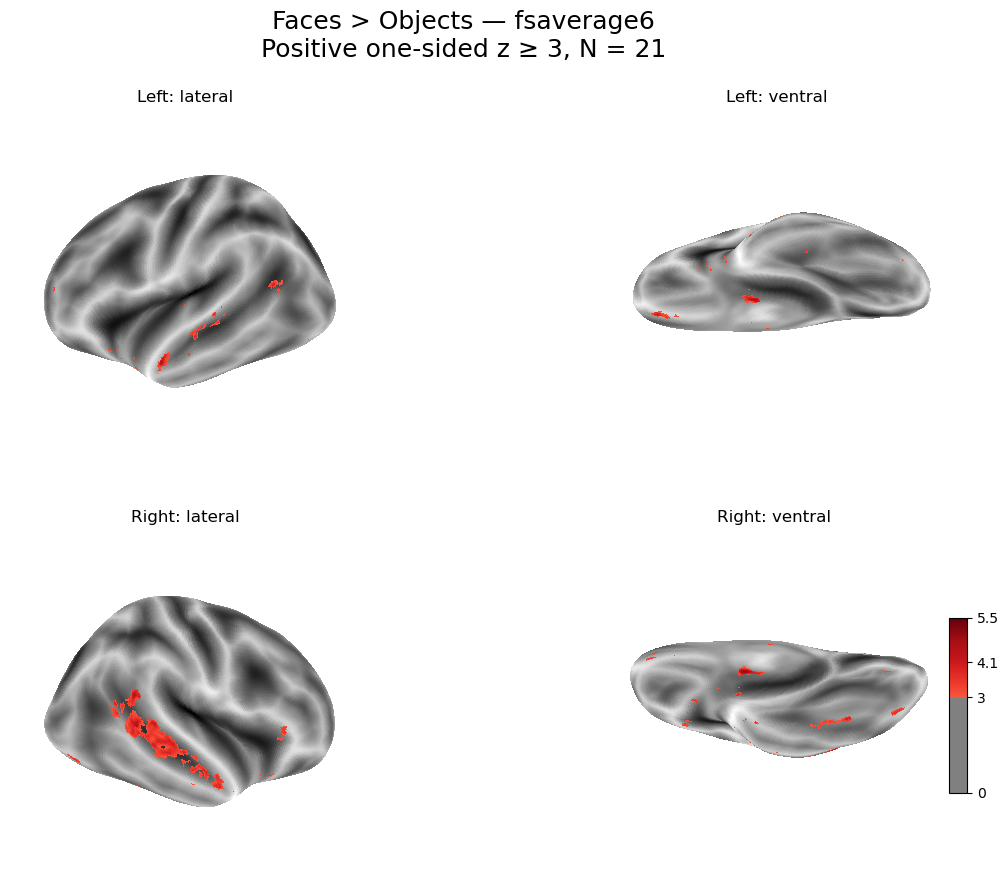

Saved figure:
/home/jovyan/heather_analysis/group_surface_faces_vs_objects/figures/group_N21_facesGreaterThanObjects_positive_z3_surface.png


[fetch_surf_fsaverage] Dataset found in /home/jovyan/nilearn_data/fsaverage6

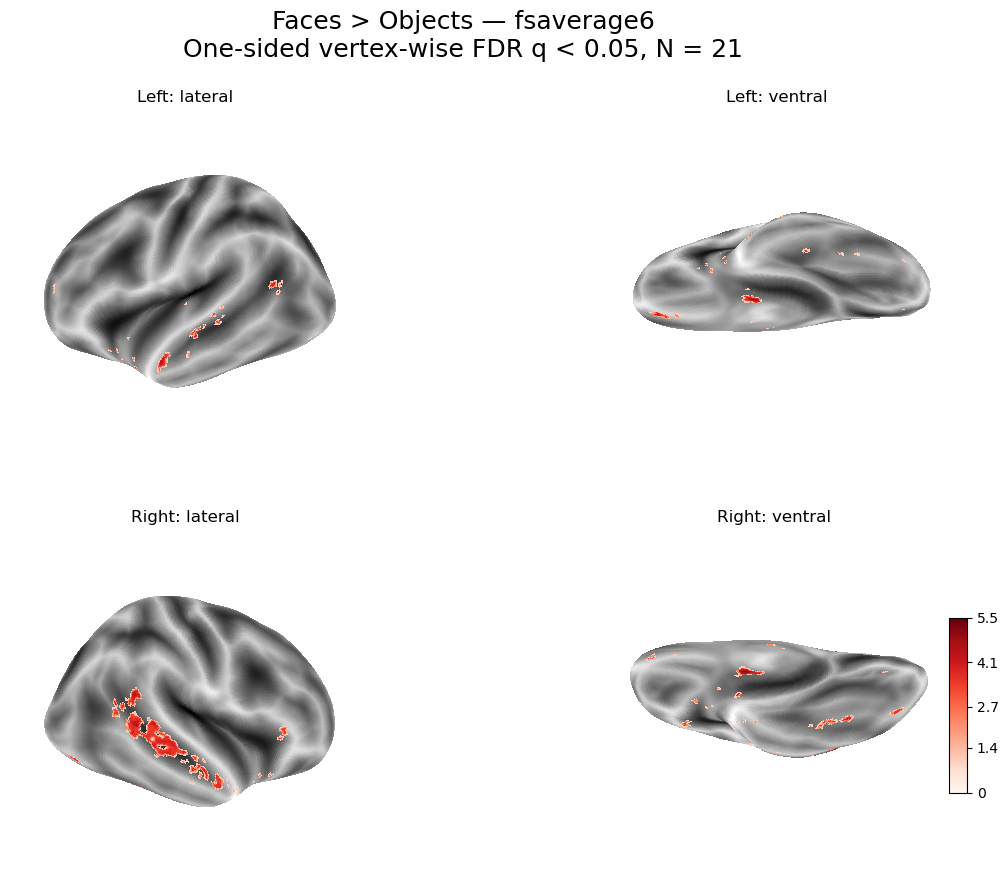

Saved figure:
/home/jovyan/heather_analysis/group_surface_faces_vs_objects/figures/group_N21_facesGreaterThanObjects_oneSidedFDRq05_surface.png


[fetch_surf_fsaverage] Dataset found in /home/jovyan/nilearn_data/fsaverage6


Analysis complete.
Display the right interactive viewer in the next notebook cell by running:
right_interactive_fdr


In [2]:
# ============================================================
# HyperFace surface group analysis
#
# Contrast:
#     Faces > Objects
#
# Analysis:
#     1. Discover first 10 subjects with downloaded localizer data
#     2. Fit first-level surface GLMs
#     3. Combine multiple runs within subjects using fixed effects
#     4. Run a group one-sample t-test
#     5. Apply one-sided Benjamini-Hochberg FDR across both hemispheres
#     6. Save maps and create final surface figures
#
# Required packages:
#     numpy, pandas, nibabel, nilearn, scipy, statsmodels, matplotlib
# ============================================================


# ============================================================
# 1. Imports
# ============================================================

from pathlib import Path
import json
import os
import warnings

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multitest import multipletests

from nilearn import datasets, plotting
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.glm.contrasts import expression_to_contrast_vector


# ============================================================
# 2. Paths and analysis settings
# ============================================================

RAW_ROOT = Path(
    "/home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007329"
)

DERIV_ROOT = Path(
    "/home/jovyan/hyperface/Grand_Budapest_Hotel_study/ds007384"
)

OUTPUT_ROOT = Path(
    "/home/jovyan/heather_analysis/group_surface_faces_vs_objects"
)

SUBJECT_OUTPUT_DIR = OUTPUT_ROOT / "subject_maps"
GROUP_OUTPUT_DIR = OUTPUT_ROOT / "group_maps"
FIGURE_OUTPUT_DIR = OUTPUT_ROOT / "figures"

for output_directory in [
    SUBJECT_OUTPUT_DIR,
    GROUP_OUTPUT_DIR,
    FIGURE_OUTPUT_DIR,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


SESSION = "ses-1"
TASK = "localizer"

N_SUBJECTS = 21

CONTRAST_EXPRESSION = "faces - objects"

HRF_MODEL = "glover"
DRIFT_MODEL = "cosine"
HIGH_PASS = 1 / 128

FDR_ALPHA = 0.05

UNCORRECTED_Z_THRESHOLD = 3.0

MOTION_COLUMNS = [
    "trans_x",
    "trans_y",
    "trans_z",
    "rot_x",
    "rot_y",
    "rot_z",
]


# ============================================================
# 3. Helper functions
# ============================================================

def path_content_exists(path):
    """
    Return True only when a file exists and its annexed content
    is available locally.

    os.path.lexists() would also return True for broken git-annex
    links, so Path.exists() is used here.
    """

    return Path(path).exists()


def extract_run_label(filename):
    """
    Extract a run label such as run-01 from a BIDS filename.
    """

    pieces = filename.split("_")

    run_pieces = [
        piece
        for piece in pieces
        if piece.startswith("run-")
    ]

    if not run_pieces:
        return None

    return run_pieces[0]


def get_run_files(subject, run):
    """
    Construct expected file paths for one subject and localizer run.
    """

    base = (
        f"{subject}_{SESSION}_task-{TASK}_{run}"
    )

    raw_func_dir = (
        RAW_ROOT
        / subject
        / SESSION
        / "func"
    )

    deriv_func_dir = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    return {
        "left_bold": (
            deriv_func_dir
            / (
                f"{base}_hemi-L_"
                "space-fsaverage6_bold.func.gii"
            )
        ),
        "right_bold": (
            deriv_func_dir
            / (
                f"{base}_hemi-R_"
                "space-fsaverage6_bold.func.gii"
            )
        ),
        "confounds": (
            deriv_func_dir
            / f"{base}_desc-confounds_timeseries.tsv"
        ),
        "events": (
            raw_func_dir
            / f"{base}_events.tsv"
        ),
    }


def find_json_sidecar(subject, run):
    """
    Search likely raw and derivative locations for a JSON sidecar
    containing RepetitionTime.
    """

    raw_func_dir = (
        RAW_ROOT
        / subject
        / SESSION
        / "func"
    )

    deriv_func_dir = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    base = (
        f"{subject}_{SESSION}_task-{TASK}_{run}"
    )

    candidates = [
        raw_func_dir / f"{base}_bold.json",
        deriv_func_dir / f"{base}_bold.json",
        deriv_func_dir / f"{base}_space-T1w_desc-preproc_bold.json",
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    broader_candidates = sorted(
        list(raw_func_dir.glob(f"{base}*bold.json"))
        + list(deriv_func_dir.glob(f"{base}*bold.json"))
    )

    if broader_candidates:
        return broader_candidates[0]

    return None


def read_repetition_time(subject, run):
    """
    Read RepetitionTime from a BIDS JSON sidecar.

    The function also checks task-level JSON files when no run-level
    JSON file is present.
    """

    run_json = find_json_sidecar(
        subject,
        run,
    )

    candidate_jsons = []

    if run_json is not None:
        candidate_jsons.append(run_json)

    candidate_jsons.extend(
        [
            RAW_ROOT
            / f"task-{TASK}_bold.json",

            RAW_ROOT
            / subject
            / SESSION
            / "func"
            / f"task-{TASK}_bold.json",

            DERIV_ROOT
            / f"task-{TASK}_bold.json",
        ]
    )

    for json_file in candidate_jsons:
        if not json_file.exists():
            continue

        with open(json_file, "r") as file:
            metadata = json.load(file)

        if "RepetitionTime" in metadata:
            repetition_time = float(
                metadata["RepetitionTime"]
            )

            print(
                f"TR for {subject} {run}: "
                f"{repetition_time} seconds"
            )

            print(
                f"TR source: {json_file}"
            )

            return repetition_time

    raise FileNotFoundError(
        f"Could not find RepetitionTime for {subject} {run}. "
        "Check the raw or derivative BIDS JSON sidecars."
    )


def load_surface_timeseries(gifti_file):
    """
    Load a functional GIFTI file.

    Returns
    -------
    data : ndarray
        Shape is scans x vertices.
    """

    gifti_image = nib.load(
        str(gifti_file)
    )

    data_arrays = [
        np.asarray(
            data_array.data,
            dtype=np.float64,
        )
        for data_array in gifti_image.darrays
    ]

    if len(data_arrays) == 0:
        raise ValueError(
            f"No data arrays found in {gifti_file}"
        )

    data = np.vstack(data_arrays)

    if data.ndim != 2:
        raise ValueError(
            f"Unexpected GIFTI data shape for {gifti_file}: "
            f"{data.shape}"
        )

    return data


def save_surface_map(
    values,
    output_file,
    intent="NIFTI_INTENT_NONE",
):
    """
    Save a one-dimensional surface map as a GIFTI file.
    """

    values = np.asarray(
        values,
        dtype=np.float32,
    )

    gifti_image = nib.gifti.GiftiImage(
        darrays=[
            nib.gifti.GiftiDataArray(
                data=values,
                intent=intent,
            )
        ]
    )

    nib.save(
        gifti_image,
        str(output_file),
    )


def identify_event_column(events_dataframe):
    """
    Identify the column containing localizer condition labels.
    """

    candidate_columns = [
        "stim_type",
        "trial_type",
        "condition",
        "category",
    ]

    for column in candidate_columns:
        if column in events_dataframe.columns:
            return column

    raise ValueError(
        "Could not identify the event-condition column. "
        f"Available columns are: "
        f"{events_dataframe.columns.tolist()}"
    )


def standardize_condition_names(series):
    """
    Standardize condition labels for contrast construction.
    """

    standardized = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    replacements = {
        "face": "faces",
        "object": "objects",
        "body": "bodies",
        "scene": "scenes",
        "scrambled_object": "scrambled_objects",
    }

    return standardized.replace(replacements)


def build_design_matrix(
    events_file,
    confounds_file,
    n_scans,
    repetition_time,
):
    """
    Build the first-level design matrix and Faces > Objects
    contrast vector for one run.
    """

    events_raw = pd.read_csv(
        events_file,
        sep="\t",
    )

    condition_column = identify_event_column(
        events_raw
    )

    required_event_columns = [
        "onset",
        "duration",
        condition_column,
    ]

    missing_event_columns = [
        column
        for column in required_event_columns
        if column not in events_raw.columns
    ]

    if missing_event_columns:
        raise ValueError(
            f"Missing event columns in {events_file}: "
            f"{missing_event_columns}"
        )

    events = events_raw[
        required_event_columns
    ].copy()

    events = events.rename(
        columns={
            condition_column: "trial_type"
        }
    )

    events["trial_type"] = standardize_condition_names(
        events["trial_type"]
    )

    available_conditions = sorted(
        events["trial_type"]
        .dropna()
        .unique()
        .tolist()
    )

    print(
        "Conditions in design:",
        available_conditions,
    )

    for required_condition in [
        "faces",
        "objects",
    ]:
        if required_condition not in available_conditions:
            raise ValueError(
                f"Condition '{required_condition}' was not found "
                f"in {events_file}. Conditions found: "
                f"{available_conditions}"
            )

    confounds_raw = pd.read_csv(
        confounds_file,
        sep="\t",
    )

    missing_motion_columns = [
        column
        for column in MOTION_COLUMNS
        if column not in confounds_raw.columns
    ]

    if missing_motion_columns:
        raise ValueError(
            f"Missing motion regressors in {confounds_file}: "
            f"{missing_motion_columns}"
        )

    confounds = (
        confounds_raw[MOTION_COLUMNS]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
        .reset_index(drop=True)
    )

    if len(confounds) != n_scans:
        raise ValueError(
            f"Confound rows ({len(confounds)}) do not match "
            f"surface scans ({n_scans}) for {events_file}."
        )

    frame_times = (
        np.arange(n_scans, dtype=float)
        * repetition_time
    )

    design_matrix = make_first_level_design_matrix(
        frame_times=frame_times,
        events=events[
            ["onset", "duration", "trial_type"]
        ],
        hrf_model=HRF_MODEL,
        drift_model=DRIFT_MODEL,
        high_pass=HIGH_PASS,
        add_regs=confounds.to_numpy(),
        add_reg_names=MOTION_COLUMNS,
    )

    contrast_vector = (
        expression_to_contrast_vector(
            CONTRAST_EXPRESSION,
            design_matrix.columns,
        )
    )

    return design_matrix, contrast_vector


def fit_surface_ols(
    surface_data,
    design_matrix,
    contrast_vector,
):
    """
    Fit an ordinary least-squares GLM at every surface vertex.

    Returns
    -------
    effect : ndarray
        Faces-minus-objects contrast estimate.

    variance : ndarray
        Estimated variance of the contrast estimate.

    t_values : ndarray
        First-level contrast t statistics.
    """

    Y = np.asarray(
        surface_data,
        dtype=np.float64,
    )

    X = np.asarray(
        design_matrix,
        dtype=np.float64,
    )

    contrast = np.asarray(
        contrast_vector,
        dtype=np.float64,
    )

    if Y.shape[0] != X.shape[0]:
        raise ValueError(
            f"Surface scans ({Y.shape[0]}) do not match "
            f"design rows ({X.shape[0]})."
        )

    finite_data_mask = np.all(
        np.isfinite(Y),
        axis=0,
    )

    Y_clean = np.nan_to_num(
        Y,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    )

    design_pseudoinverse = np.linalg.pinv(X)

    beta = (
        design_pseudoinverse
        @ Y_clean
    )

    fitted = X @ beta

    residuals = (
        Y_clean
        - fitted
    )

    design_rank = np.linalg.matrix_rank(X)

    residual_degrees_of_freedom = (
        X.shape[0]
        - design_rank
    )

    if residual_degrees_of_freedom <= 0:
        raise ValueError(
            "The first-level model has no residual "
            "degrees of freedom."
        )

    residual_variance = (
        np.sum(
            residuals ** 2,
            axis=0,
        )
        / residual_degrees_of_freedom
    )

    xtx_inverse = np.linalg.pinv(
        X.T @ X
    )

    contrast_scale = float(
        contrast.T
        @ xtx_inverse
        @ contrast
    )

    effect = contrast @ beta

    variance = (
        residual_variance
        * contrast_scale
    )

    valid_variance_mask = (
        finite_data_mask
        & np.isfinite(effect)
        & np.isfinite(variance)
        & (variance > 0)
    )

    t_values = np.zeros_like(
        effect,
        dtype=float,
    )

    t_values[valid_variance_mask] = (
        effect[valid_variance_mask]
        / np.sqrt(
            variance[valid_variance_mask]
        )
    )

    effect[~finite_data_mask] = 0
    variance[~valid_variance_mask] = np.inf

    return effect, variance, t_values


def fixed_effects_combine(
    effects,
    variances,
):
    """
    Combine multiple localizer runs within a subject using
    inverse-variance fixed effects.
    """

    effects = np.asarray(
        effects,
        dtype=np.float64,
    )

    variances = np.asarray(
        variances,
        dtype=np.float64,
    )

    valid = (
        np.isfinite(effects)
        & np.isfinite(variances)
        & (variances > 0)
    )

    weights = np.zeros_like(
        variances,
        dtype=float,
    )

    weights[valid] = (
        1.0
        / variances[valid]
    )

    weight_sum = np.sum(
        weights,
        axis=0,
    )

    combined_effect = np.zeros(
        effects.shape[1],
        dtype=float,
    )

    combined_variance = np.full(
        effects.shape[1],
        np.inf,
        dtype=float,
    )

    valid_vertices = weight_sum > 0

    weighted_effect_sum = np.sum(
        weights * effects,
        axis=0,
    )

    combined_effect[valid_vertices] = (
        weighted_effect_sum[valid_vertices]
        / weight_sum[valid_vertices]
    )

    combined_variance[valid_vertices] = (
        1.0
        / weight_sum[valid_vertices]
    )

    return combined_effect, combined_variance


def group_one_sample_test(subject_effects):
    """
    Perform a vertex-wise one-sample t-test across subjects.

    Returns
    -------
    group_mean
    group_t
    group_z_two_sided
    valid_vertices
    """

    subject_effects = np.asarray(
        subject_effects,
        dtype=np.float64,
    )

    n_subjects = subject_effects.shape[0]

    group_mean = np.mean(
        subject_effects,
        axis=0,
    )

    group_standard_deviation = np.std(
        subject_effects,
        axis=0,
        ddof=1,
    )

    group_standard_error = (
        group_standard_deviation
        / np.sqrt(n_subjects)
    )

    # Exclude medial-wall and constant vertices.
    nonzero_across_subjects = np.any(
        np.abs(subject_effects) > 1e-12,
        axis=0,
    )

    valid_vertices = (
        np.all(
            np.isfinite(subject_effects),
            axis=0,
        )
        & np.isfinite(group_mean)
        & np.isfinite(group_standard_error)
        & (group_standard_error > 0)
        & nonzero_across_subjects
    )

    group_t = np.zeros_like(
        group_mean,
        dtype=float,
    )

    group_t[valid_vertices] = (
        group_mean[valid_vertices]
        / group_standard_error[valid_vertices]
    )

    degrees_of_freedom = (
        n_subjects - 1
    )

    two_sided_p = np.ones_like(
        group_t,
        dtype=float,
    )

    two_sided_p[valid_vertices] = (
        2
        * stats.t.sf(
            np.abs(
                group_t[valid_vertices]
            ),
            df=degrees_of_freedom,
        )
    )

    two_sided_p = np.clip(
        two_sided_p,
        np.finfo(float).tiny,
        1.0,
    )

    group_z_two_sided = np.zeros_like(
        group_t,
        dtype=float,
    )

    group_z_two_sided[valid_vertices] = (
        stats.norm.isf(
            two_sided_p[valid_vertices]
            / 2
        )
        * np.sign(
            group_t[valid_vertices]
        )
    )

    return (
        group_mean,
        group_t,
        group_z_two_sided,
        valid_vertices,
    )


def plot_surface_four_views(
    left_stat_map,
    right_stat_map,
    figure_title,
    output_file,
    threshold,
    cmap="Reds",
    symmetric_cbar=False,
    vmax=None,
):
    """
    Create left/right lateral and ventral surface plots.
    """

    fsaverage = datasets.fetch_surf_fsaverage(
        mesh="fsaverage6"
    )

    views = [
        ("left", "lateral"),
        ("left", "ventral"),
        ("right", "lateral"),
        ("right", "ventral"),
    ]

    figure = plt.figure(
        figsize=(14, 10)
    )

    for plot_number, (
        hemisphere,
        view,
    ) in enumerate(
        views,
        start=1,
    ):

        axis = figure.add_subplot(
            2,
            2,
            plot_number,
            projection="3d",
        )

        if hemisphere == "left":
            stat_map = left_stat_map
            surface_mesh = fsaverage.infl_left
            background_map = fsaverage.sulc_left
            hemisphere_label = "Left"
        else:
            stat_map = right_stat_map
            surface_mesh = fsaverage.infl_right
            background_map = fsaverage.sulc_right
            hemisphere_label = "Right"

        plotting.plot_surf_stat_map(
            surf_mesh=surface_mesh,
            stat_map=stat_map,
            bg_map=background_map,
            hemi=hemisphere,
            view=view,
            threshold=threshold,
            cmap=cmap,
            symmetric_cbar=symmetric_cbar,
            vmax=vmax,
            colorbar=(plot_number == 4),
            title=(
                f"{hemisphere_label}: "
                f"{view}"
            ),
            axes=axis,
        )

    figure.suptitle(
        figure_title,
        fontsize=18,
        y=0.98,
    )

    figure.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved figure:\n{output_file}"
    )


# ============================================================
# 4. Discover complete downloaded localizer runs
# ============================================================

all_subjects = sorted(
    [
        path.name
        for path in DERIV_ROOT.glob("sub-*")
        if path.is_dir()
    ]
)

subject_runs = {}

for subject in all_subjects:

    derivative_func_directory = (
        DERIV_ROOT
        / subject
        / SESSION
        / "func"
    )

    if not derivative_func_directory.exists():
        continue

    left_candidates = sorted(
        derivative_func_directory.glob(
            (
                f"{subject}_{SESSION}_"
                f"task-{TASK}_run-*_"
                "hemi-L_space-fsaverage6_bold.func.gii"
            )
        )
    )

    complete_runs = []

    for left_candidate in left_candidates:

        run = extract_run_label(
            left_candidate.name
        )

        if run is None:
            continue

        files = get_run_files(
            subject,
            run,
        )

        if all(
            path_content_exists(path)
            for path in files.values()
        ):
            complete_runs.append(run)

    if complete_runs:
        subject_runs[subject] = sorted(
            set(complete_runs)
        )


eligible_subjects = sorted(
    subject_runs.keys()
)

subjects = eligible_subjects[
    :N_SUBJECTS
]

print(
    "Total subject directories:",
    len(all_subjects),
)

print(
    "Subjects with at least one complete downloaded "
    "surface localizer run:",
    len(eligible_subjects),
)

print(
    "Subjects selected:",
    len(subjects),
)

print(
    "\nSelected subjects and runs:"
)

for subject in subjects:
    print(
        f"  {subject}: "
        f"{subject_runs[subject]}"
    )

if len(subjects) == 0:
    raise RuntimeError(
        "No complete downloaded localizer surface data were found."
    )

if len(subjects) < N_SUBJECTS:
    warnings.warn(
        f"Only {len(subjects)} complete subjects were found. "
        f"The analysis will use those subjects rather than "
        f"the requested {N_SUBJECTS}."
    )


# ============================================================
# 5. Fit first-level GLMs and combine runs within subjects
# ============================================================

left_subject_effects = []
right_subject_effects = []

processing_rows = []

expected_left_vertices = None
expected_right_vertices = None


for subject_index, subject in enumerate(
    subjects,
    start=1,
):

    print("\n" + "=" * 80)

    print(
        f"Processing subject "
        f"{subject_index}/{len(subjects)}: "
        f"{subject}"
    )

    print("=" * 80)

    available_runs = subject_runs[
        subject
    ]

    left_run_effects = []
    left_run_variances = []

    right_run_effects = []
    right_run_variances = []

    successful_runs = []

    for run in available_runs:

        print(
            f"\nProcessing {run}"
        )

        files = get_run_files(
            subject,
            run,
        )

        left_data = load_surface_timeseries(
            files["left_bold"]
        )

        right_data = load_surface_timeseries(
            files["right_bold"]
        )

        print(
            "Left surface shape:",
            left_data.shape,
        )

        print(
            "Right surface shape:",
            right_data.shape,
        )

        if (
            left_data.shape[0]
            != right_data.shape[0]
        ):
            raise ValueError(
                f"{subject} {run}: left and right hemispheres "
                "have different numbers of scans."
            )

        if expected_left_vertices is None:
            expected_left_vertices = (
                left_data.shape[1]
            )

            expected_right_vertices = (
                right_data.shape[1]
            )

        if (
            left_data.shape[1]
            != expected_left_vertices
        ):
            raise ValueError(
                f"{subject} {run}: unexpected number of "
                "left-hemisphere vertices."
            )

        if (
            right_data.shape[1]
            != expected_right_vertices
        ):
            raise ValueError(
                f"{subject} {run}: unexpected number of "
                "right-hemisphere vertices."
            )

        repetition_time = read_repetition_time(
            subject,
            run,
        )

        (
            design_matrix,
            contrast_vector,
        ) = build_design_matrix(
            events_file=files["events"],
            confounds_file=files["confounds"],
            n_scans=left_data.shape[0],
            repetition_time=repetition_time,
        )

        print(
            "Design matrix shape:",
            design_matrix.shape,
        )

        print(
            "Design matrix columns:"
        )

        print(
            design_matrix.columns.tolist()
        )

        print(
            "Fitting left hemisphere..."
        )

        (
            left_effect,
            left_variance,
            left_t,
        ) = fit_surface_ols(
            surface_data=left_data,
            design_matrix=design_matrix,
            contrast_vector=contrast_vector,
        )

        print(
            "Fitting right hemisphere..."
        )

        (
            right_effect,
            right_variance,
            right_t,
        ) = fit_surface_ols(
            surface_data=right_data,
            design_matrix=design_matrix,
            contrast_vector=contrast_vector,
        )

        left_run_effects.append(
            left_effect
        )

        left_run_variances.append(
            left_variance
        )

        right_run_effects.append(
            right_effect
        )

        right_run_variances.append(
            right_variance
        )

        successful_runs.append(run)

        np.save(
            SUBJECT_OUTPUT_DIR
            / (
                f"{subject}_{run}_hemi-L_"
                "facesMinusObjects_effect.npy"
            ),
            left_effect,
        )

        np.save(
            SUBJECT_OUTPUT_DIR
            / (
                f"{subject}_{run}_hemi-R_"
                "facesMinusObjects_effect.npy"
            ),
            right_effect,
        )

    if len(successful_runs) == 0:
        print(
            f"No successful runs for {subject}; "
            "subject will be skipped."
        )

        continue

    (
        left_subject_effect,
        left_subject_variance,
    ) = fixed_effects_combine(
        effects=np.vstack(
            left_run_effects
        ),
        variances=np.vstack(
            left_run_variances
        ),
    )

    (
        right_subject_effect,
        right_subject_variance,
    ) = fixed_effects_combine(
        effects=np.vstack(
            right_run_effects
        ),
        variances=np.vstack(
            right_run_variances
        ),
    )

    left_subject_effects.append(
        left_subject_effect
    )

    right_subject_effects.append(
        right_subject_effect
    )

    left_subject_effect_file = (
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-L_space-fsaverage6_"
            "facesMinusObjects_effect.func.gii"
        )
    )

    right_subject_effect_file = (
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-R_space-fsaverage6_"
            "facesMinusObjects_effect.func.gii"
        )
    )

    save_surface_map(
        left_subject_effect,
        left_subject_effect_file,
    )

    save_surface_map(
        right_subject_effect,
        right_subject_effect_file,
    )

    np.save(
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-L_"
            "facesMinusObjects_variance.npy"
        ),
        left_subject_variance,
    )

    np.save(
        SUBJECT_OUTPUT_DIR
        / (
            f"{subject}_hemi-R_"
            "facesMinusObjects_variance.npy"
        ),
        right_subject_variance,
    )

    processing_rows.append(
        {
            "subject": subject,
            "runs": ",".join(
                successful_runs
            ),
            "number_of_runs": len(
                successful_runs
            ),
            "left_vertices": len(
                left_subject_effect
            ),
            "right_vertices": len(
                right_subject_effect
            ),
            "status": "complete",
        }
    )

    print(
        f"Completed {subject}"
    )


processing_summary = pd.DataFrame(
    processing_rows
)

processing_summary_file = (
    OUTPUT_ROOT
    / "processing_summary.tsv"
)

processing_summary.to_csv(
    processing_summary_file,
    sep="\t",
    index=False,
)

print(
    "\nProcessing summary:"
)

print(
    processing_summary.to_string(
        index=False
    )
)

print(
    f"\nSaved summary:\n"
    f"{processing_summary_file}"
)


# ============================================================
# 6. Group-level one-sample tests
# ============================================================

left_subject_effects = np.vstack(
    left_subject_effects
)

right_subject_effects = np.vstack(
    right_subject_effects
)

n_group_subjects = (
    left_subject_effects.shape[0]
)

if n_group_subjects < 2:
    raise RuntimeError(
        "At least two subjects are required for the group test."
    )

print(
    "\nGroup sample size:",
    n_group_subjects,
)

print(
    "Left subject-by-vertex matrix:",
    left_subject_effects.shape,
)

print(
    "Right subject-by-vertex matrix:",
    right_subject_effects.shape,
)


(
    left_group_mean,
    left_group_t,
    left_group_z,
    left_valid_vertices,
) = group_one_sample_test(
    left_subject_effects
)

(
    right_group_mean,
    right_group_t,
    right_group_z,
    right_valid_vertices,
) = group_one_sample_test(
    right_subject_effects
)


# ============================================================
# 7. One-sided FDR: Faces > Objects
# ============================================================

group_degrees_of_freedom = (
    n_group_subjects - 1
)

left_positive_p = np.ones_like(
    left_group_t,
    dtype=float,
)

right_positive_p = np.ones_like(
    right_group_t,
    dtype=float,
)


left_positive_test_mask = (
    left_valid_vertices
    & np.isfinite(left_group_t)
    & (left_group_t > 0)
)

right_positive_test_mask = (
    right_valid_vertices
    & np.isfinite(right_group_t)
    & (right_group_t > 0)
)


left_positive_p[
    left_positive_test_mask
] = stats.t.sf(
    left_group_t[
        left_positive_test_mask
    ],
    df=group_degrees_of_freedom,
)

right_positive_p[
    right_positive_test_mask
] = stats.t.sf(
    right_group_t[
        right_positive_test_mask
    ],
    df=group_degrees_of_freedom,
)


all_positive_p = np.concatenate(
    [
        left_positive_p,
        right_positive_p,
    ]
)

all_tested_vertices = np.concatenate(
    [
        left_valid_vertices,
        right_valid_vertices,
    ]
)

reject_all = np.zeros(
    all_positive_p.shape,
    dtype=bool,
)

q_all = np.full(
    all_positive_p.shape,
    np.nan,
    dtype=float,
)


tested_p_values = all_positive_p[
    all_tested_vertices
]

(
    tested_rejections,
    tested_q_values,
    _,
    _,
) = multipletests(
    tested_p_values,
    alpha=FDR_ALPHA,
    method="fdr_bh",
)

reject_all[
    all_tested_vertices
] = tested_rejections

q_all[
    all_tested_vertices
] = tested_q_values


n_left_vertices = len(
    left_group_t
)

left_faces_fdr_mask = reject_all[
    :n_left_vertices
]

right_faces_fdr_mask = reject_all[
    n_left_vertices:
]

left_faces_q = q_all[
    :n_left_vertices
]

right_faces_q = q_all[
    n_left_vertices:
]


# Convert one-sided p-values to positive z statistics.
left_positive_z = np.zeros_like(
    left_group_t,
    dtype=float,
)

right_positive_z = np.zeros_like(
    right_group_t,
    dtype=float,
)


left_positive_z[
    left_positive_test_mask
] = stats.norm.isf(
    np.clip(
        left_positive_p[
            left_positive_test_mask
        ],
        np.finfo(float).tiny,
        1.0,
    )
)

right_positive_z[
    right_positive_test_mask
] = stats.norm.isf(
    np.clip(
        right_positive_p[
            right_positive_test_mask
        ],
        np.finfo(float).tiny,
        1.0,
    )
)


left_group_z_faces_fdr = np.where(
    left_faces_fdr_mask,
    left_positive_z,
    0.0,
)

right_group_z_faces_fdr = np.where(
    right_faces_fdr_mask,
    right_positive_z,
    0.0,
)


print(
    "\nGroup degrees of freedom:",
    group_degrees_of_freedom,
)

print(
    "Valid left-hemisphere vertices:",
    int(
        left_valid_vertices.sum()
    ),
)

print(
    "Valid right-hemisphere vertices:",
    int(
        right_valid_vertices.sum()
    ),
)

print(
    "Significant left Faces > Objects vertices:",
    int(
        left_faces_fdr_mask.sum()
    ),
)

print(
    "Significant right Faces > Objects vertices:",
    int(
        right_faces_fdr_mask.sum()
    ),
)

print(
    "Total significant Faces > Objects vertices:",
    int(
        left_faces_fdr_mask.sum()
        + right_faces_fdr_mask.sum()
    ),
)

print(
    "Maximum left group t:",
    float(
        np.nanmax(left_group_t)
    ),
)

print(
    "Maximum right group t:",
    float(
        np.nanmax(right_group_t)
    ),
)


# ============================================================
# 8. Save group maps
# ============================================================

group_prefix = (
    f"group_N{n_group_subjects}_"
    "facesMinusObjects"
)


maps_to_save = [
    (
        left_group_mean,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "meanEffect.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
    (
        right_group_mean,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "meanEffect.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
    (
        left_group_t,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "tmap.func.gii"
        ),
        "NIFTI_INTENT_TTEST",
    ),
    (
        right_group_t,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "tmap.func.gii"
        ),
        "NIFTI_INTENT_TTEST",
    ),
    (
        left_positive_z,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "positiveOneSided_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        right_positive_z,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "positiveOneSided_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        left_group_z_faces_fdr,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "oneSidedFDRq05_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        right_group_z_faces_fdr,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "oneSidedFDRq05_zmap.func.gii"
        ),
        "NIFTI_INTENT_ZSCORE",
    ),
    (
        left_faces_q,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-L_"
            "oneSided_qvalues.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
    (
        right_faces_q,
        GROUP_OUTPUT_DIR
        / (
            f"{group_prefix}_hemi-R_"
            "oneSided_qvalues.func.gii"
        ),
        "NIFTI_INTENT_NONE",
    ),
]


for (
    values,
    output_file,
    intent,
) in maps_to_save:

    save_surface_map(
        values,
        output_file,
        intent=intent,
    )

    print(
        f"Saved map:\n{output_file}"
    )


# ============================================================
# 9. Positive uncorrected diagnostic figure
#
# This plot is useful for examining the expected spatial pattern.
# It is not the FDR-corrected inferential result.
# ============================================================

positive_z_values = np.concatenate(
    [
        left_positive_z[
            left_positive_z
            >= UNCORRECTED_Z_THRESHOLD
        ],
        right_positive_z[
            right_positive_z
            >= UNCORRECTED_Z_THRESHOLD
        ],
    ]
)

if positive_z_values.size > 0:

    uncorrected_vmax = float(
        np.nanmax(
            positive_z_values
        )
    )

    uncorrected_figure_file = (
        FIGURE_OUTPUT_DIR
        / (
            f"group_N{n_group_subjects}_"
            "facesGreaterThanObjects_"
            "positive_z3_surface.png"
        )
    )

    plot_surface_four_views(
        left_stat_map=left_positive_z,
        right_stat_map=right_positive_z,
        figure_title=(
            "Faces > Objects — fsaverage6\n"
            f"Positive one-sided z ≥ "
            f"{UNCORRECTED_Z_THRESHOLD:g}, "
            f"N = {n_group_subjects}"
        ),
        output_file=uncorrected_figure_file,
        threshold=UNCORRECTED_Z_THRESHOLD,
        cmap="Reds",
        symmetric_cbar=False,
        vmax=uncorrected_vmax,
    )

else:

    print(
        "\nNo positive vertices exceeded "
        f"z = {UNCORRECTED_Z_THRESHOLD:g}; "
        "the uncorrected diagnostic figure was not created."
    )


# ============================================================
# 10. Final one-sided FDR-corrected figure
# ============================================================

fdr_positive_values = np.concatenate(
    [
        left_group_z_faces_fdr[
            left_group_z_faces_fdr > 0
        ],
        right_group_z_faces_fdr[
            right_group_z_faces_fdr > 0
        ],
    ]
)

if fdr_positive_values.size > 0:

    fdr_vmax = float(
        np.nanmax(
            fdr_positive_values
        )
    )

    fdr_figure_file = (
        FIGURE_OUTPUT_DIR
        / (
            f"group_N{n_group_subjects}_"
            "facesGreaterThanObjects_"
            "oneSidedFDRq05_surface.png"
        )
    )

    plot_surface_four_views(
        left_stat_map=left_group_z_faces_fdr,
        right_stat_map=right_group_z_faces_fdr,
        figure_title=(
            "Faces > Objects — fsaverage6\n"
            "One-sided vertex-wise FDR "
            f"q < {FDR_ALPHA:g}, "
            f"N = {n_group_subjects}"
        ),
        output_file=fdr_figure_file,
        threshold=1e-12,
        cmap="Reds",
        symmetric_cbar=False,
        vmax=fdr_vmax,
    )

else:

    print(
        "\nNo positive Faces > Objects vertices survived "
        f"whole-cortex FDR q < {FDR_ALPHA:g}."
    )

    print(
        "The uncorrected positive z-map was still saved "
        "for diagnostic visualization."
    )


# ============================================================
# 11. Interactive FDR-corrected viewers
# ============================================================

fsaverage = datasets.fetch_surf_fsaverage(
    mesh="fsaverage6"
)

if fdr_positive_values.size > 0:

    left_interactive_fdr = plotting.view_surf(
        surf_mesh=fsaverage.infl_left,
        surf_map=left_group_z_faces_fdr,
        bg_map=fsaverage.sulc_left,
        threshold=1e-12,
        symmetric_cmap=False,
        cmap="Reds",
        title=(
            "Faces > Objects: left hemisphere, "
            f"FDR q < {FDR_ALPHA:g}, "
            f"N={n_group_subjects}"
        ),
    )

    right_interactive_fdr = plotting.view_surf(
        surf_mesh=fsaverage.infl_right,
        surf_map=right_group_z_faces_fdr,
        bg_map=fsaverage.sulc_right,
        threshold=1e-12,
        symmetric_cmap=False,
        cmap="Reds",
        title=(
            "Faces > Objects: right hemisphere, "
            f"FDR q < {FDR_ALPHA:g}, "
            f"N={n_group_subjects}"
        ),
    )

    print(
        "\nAnalysis complete."
    )

    print(
        "Display the right interactive viewer in the "
        "next notebook cell by running:"
    )

    print(
        "right_interactive_fdr"
    )

    left_interactive_fdr

else:

    print(
        "\nAnalysis complete, but no vertices survived FDR."
    )